In [1]:
# ============================================================
# PASO 0 — LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score
)


In [2]:
# -------------------------------------------------------
# 1. Cargar los datos
# -------------------------------------------------------
# Ruta de tu archivo CSV (ajústala a tu disco)

BASEFINALAGRUPADA = pd.read_csv(r'C:\Users\garci\OneDrive\Programacion\01.Data\BASEFINALAGRUPADA.csv',
                               sep=';',
                               engine='python'
                               )

In [3]:
# ============================================================
# PASO 1 — BASE
# ============================================================

df = BASEFINALAGRUPADA.copy()
df.columns = df.columns.str.strip()


In [4]:
# ============================================================
# PASO 2 — VARIABLES CLAVE
# ============================================================

target_var = "MULTA"
year_var = "AÑO FIRMA CONTRATO"

id_cols = [
    "ID_NOMBRE_CONTRATISTA",
    "NIT_NOMBRE_CONTRATANTE",
    "NUMERO CONTRATO"
]


In [5]:
# ============================================================
# PASO 3 — VARIABLE PLAZO (RECOMENDADO)
# ============================================================

if "AÑO INICIO CONTRATO" in df.columns and "AÑO FINAL DEL CONTRATO" in df.columns:

    df["PLAZO_CONTRATO"] = (
        df["AÑO FINAL DEL CONTRATO"] - df["AÑO INICIO CONTRATO"]
    )

    df["PLAZO_CONTRATO"] = df["PLAZO_CONTRATO"].clip(lower=0)

    df = df.drop(columns=[
        "AÑO INICIO CONTRATO",
        "AÑO FINAL DEL CONTRATO"
    ])


In [6]:
# ============================================================
# PASO 4 — SPLIT TEMPORAL
# ============================================================

cut_year = 2020

train_df = df[df[year_var] < cut_year]
test_df  = df[df[year_var] >= cut_year]

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (123480, 163)
Test : (366100, 163)


In [7]:
# ============================================================
# PASO 5 — DEFINIR X / y
# ============================================================

X_train = train_df.drop(columns=[target_var])
y_train = train_df[target_var]

X_test = test_df.drop(columns=[target_var])
y_test = test_df[target_var]

# ⚠️ eliminar año del modelo
X_train = X_train.drop(columns=[year_var], errors="ignore")
X_test  = X_test.drop(columns=[year_var], errors="ignore")


In [8]:
# ============================================================
# PASO 6 — TIPOS DE VARIABLES
# ============================================================

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [9]:
# ============================================================
# PASO 7 — REDUCIR CARDINALIDAD (CLAVE)
# ============================================================

for col in categorical_cols:
    if col in X_train.columns:

        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

        top = X_train[col].value_counts().nlargest(20).index

        X_train[col] = X_train[col].where(
            X_train[col].isin(top), "OTROS"
        )

        X_test[col] = X_test[col].where(
            X_test[col].isin(top), "OTROS"
        )


In [10]:
# ============================================================
# PASO 8 — PREPROCESAMIENTO (LIGERO)
# ============================================================

num_transformer = SimpleImputer(strategy="median")

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("cat", cat_transformer, categorical_cols),
    ("num", num_transformer, numeric_cols)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


In [11]:
# ============================================================
# PASO 9 — MODELO + CV
# ============================================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=6,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train_enc, y_train)

print("\nMejores parámetros:", random_search.best_params_)
print("Mejor AUC CV:", random_search.best_score_)

best_model = random_search.best_estimator_


Fitting 3 folds for each of 6 candidates, totalling 18 fits

Mejores parámetros: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Mejor AUC CV: 0.970782174848558


In [12]:
# ============================================================
# PASO 10 — PREDICCIÓN (DESBALANCE)
# ============================================================

test_probs = best_model.predict_proba(X_test_enc)[:,1]

threshold = 0.1   # 🔥 clave para pocos positivos
y_pred = (test_probs > threshold).astype(int)

print("\nDistribución predicciones:")
print(pd.Series(y_pred).value_counts())



Distribución predicciones:
0    365781
1       319
Name: count, dtype: int64


In [13]:
# ============================================================
# PASO 11 — MÉTRICAS
# ============================================================

print("\nRESULTADOS:")

print("AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


RESULTADOS:
AUC: 0.5648425572575462
Precision: 0.009404388714733543
Recall: 0.02027027027027027
F1: 0.01284796573875803


In [14]:
# ============================================================
# PASO 12 — ALERTAS (TIPO DOCUMENTO)
# ============================================================

alertas = pd.DataFrame({
    "Probabilidad": test_probs
})

alertas["Score"] = alertas["Probabilidad"] * 100

alertas["Nivel"] = pd.cut(
    alertas["Score"],
    bins=[0, 25, 50, 75, 100],
    labels=["Bajo", "Medio Bajo", "Medio Alto", "Alto"]
)

print("\nDistribución de alertas:")
print(alertas["Nivel"].value_counts())



Distribución de alertas:
Nivel
Bajo          366100
Medio Bajo         0
Medio Alto         0
Alto               0
Name: count, dtype: int64


In [15]:
# ============================================================
# PASO 13 — ALERTAS ECONÓMICAS
# ============================================================

if "VALOR CONTRATO" in X_test.columns:

    alertas["Valor_Contrato"] = pd.to_numeric(
        X_test["VALOR CONTRATO"], errors="coerce"
    )

    alertas["Perdida_Esperada"] = (
        alertas["Probabilidad"] * alertas["Valor_Contrato"]
    )

    print("\nTop riesgo económico:")
    print(alertas.sort_values(
        by="Perdida_Esperada",
        ascending=False
    ).head(10))


Top riesgo económico:
   Probabilidad     Score Nivel  Valor_Contrato  Perdida_Esperada
0      0.045574  4.557433  Bajo             NaN               NaN
1      0.045574  4.557433  Bajo             NaN               NaN
2      0.023379  2.337935  Bajo             NaN               NaN
3      0.035954  3.595399  Bajo             NaN               NaN
4      0.018273  1.827335  Bajo             NaN               NaN
5      0.030091  3.009104  Bajo             NaN               NaN
6      0.011404  1.140389  Bajo             NaN               NaN
7      0.023218  2.321806  Bajo             NaN               NaN
8      0.014737  1.473669  Bajo             NaN               NaN
9      0.028209  2.820876  Bajo             NaN               NaN


In [16]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

import pandas as pd

# nombres de variables (incluye OneHot)
feature_names = preprocessor.get_feature_names_out()

# importancia
importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importance
}).sort_values(by="Importancia", ascending=False)

print("\nTop 10 variables más importantes:")
print(importance_df.head(10))


Top 10 variables más importantes:
                                               Variable  Importancia
2891                    num__JUSTIFICACION DEL CONTRATO     0.022803
2888                               num__ESTADO CONTRATO     0.018198
1278                cat__CAPACIDAD ADMINISTRATIVA_83,66     0.018188
833   cat__NUMERO DE MATRICULADOS A EDUCACION SUPERI...     0.017241
1660                                 cat__MONTO TOTAL_0     0.015925
2890                     num__MODALIDAD DE CONTRATACION     0.014140
2017         cat__NRO CTA AHORRO ELECTRONICAS MUJERES_0     0.013798
1933                       cat__NRO TOTAL CTA AHORROS_0     0.013524
388                      cat__HURTOS PERSONAS_37.954,00     0.013483
2898          num__SECTOR ECONOMICO ENTIDAD CONTRATANTE     0.013447


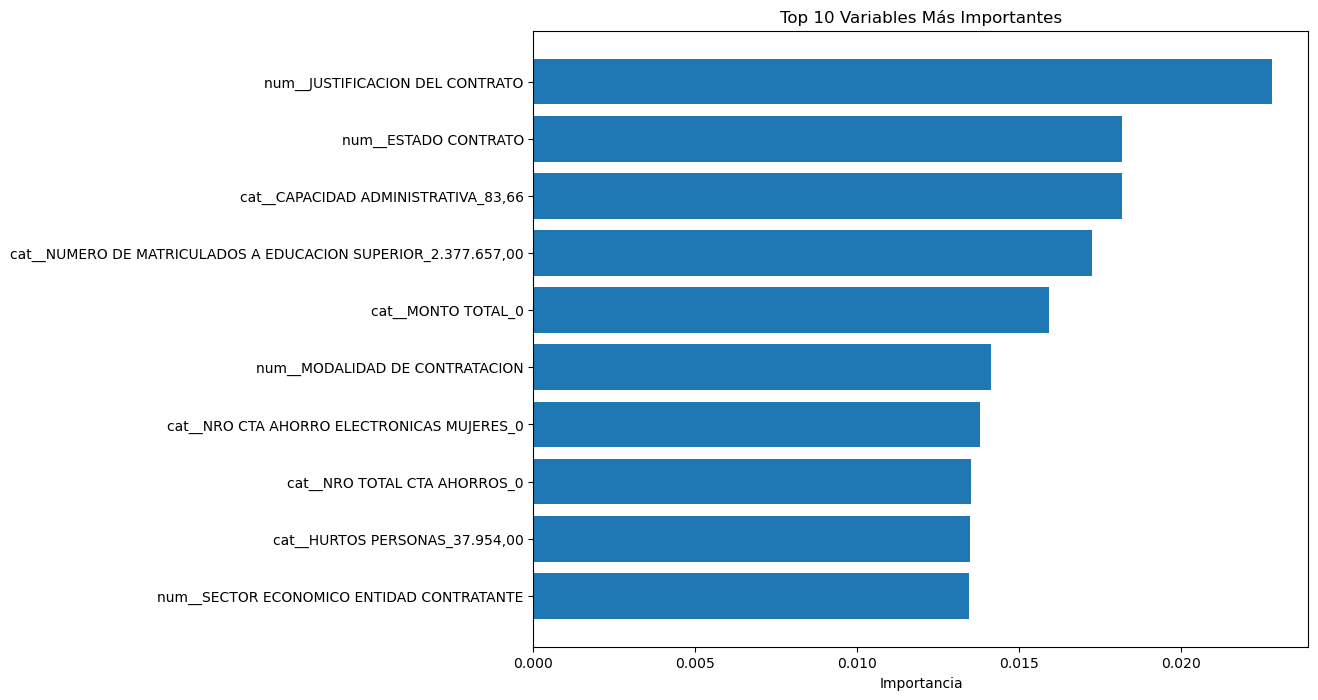

In [18]:
# ============================================================
# GRÁFICA IMPORTANCIA
# ============================================================

import matplotlib.pyplot as plt

top_n = 10
top_vars = importance_df.head(top_n)

plt.figure(figsize=(10,8))
plt.barh(top_vars["Variable"], top_vars["Importancia"])
plt.gca().invert_yaxis()
plt.title("Top 10 Variables Más Importantes")
plt.xlabel("Importancia")
plt.show()

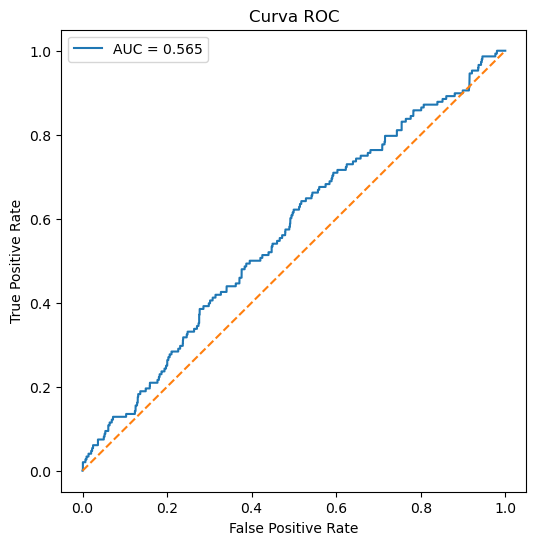

In [19]:
# ============================================================
# CURVA ROC
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

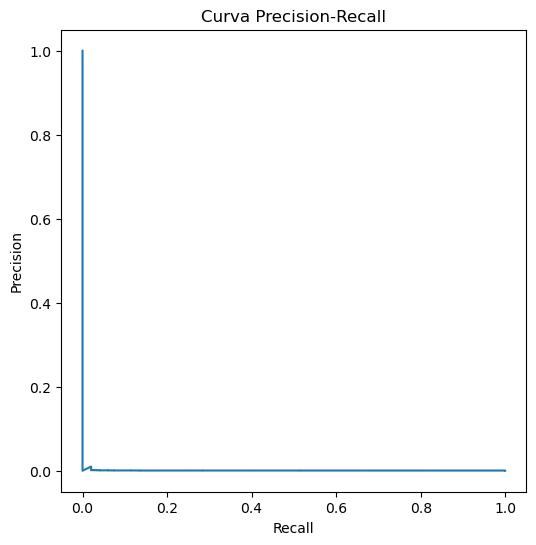

In [21]:
# ============================================================
# CURVA PRECISION-RECALL
# ============================================================

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test, test_probs
)

plt.figure(figsize=(6,6))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

In [22]:
# ============================================================
# MEJOR THRESHOLD (OPCIONAL)
# ============================================================

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)

best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]

print("Mejor threshold:", best_threshold)
print("Mejor F1:", f1_scores[best_idx])

Mejor threshold: 0.10047608333540525
Mejor F1: 0.013274331878770354
